In [ ]:
'''
p300_transformer_project/
├── data/
│   └── (сюда положишь данные от Александра)
├── models/
│   ├── __init__.py
│   ├── s3t.py          # твоя имплементация S3T
│   ├── eegnet.py       # для сравнения (можно взять из braindecode)
│   └── baseline.py     # LDA/RandomForest для сравнения
├── utils/
│   ├── dataloader.py   # загрузка данных
│   ├── preprocessing.py # фильтрация, нормализация
│   └── metrics.py      # accuracy, f1, confusion matrix
├── train.py            # основной скрипт обучения
├── evaluate.py         # сравнение моделей
└── experiments.ipynb   # для быстрых экспериментов
'''

In [ ]:
'''
"""
preprocessing.py - предобработка данных P300 для трансформера S3T
Основано на данных из статьи Kirasirova et al. 2021
"""

import numpy as np
from scipy import signal
from typing import Tuple, Optional

def normalize_epochs(epochs: np.ndarray, method: str = 'zscore') -> np.ndarray:
    """Нормализация эпох (обязательно!)"""
    # код выше

def create_p300_sequences(epochs: np.ndarray, 
                          labels: np.ndarray, 
                          seq_length: int = 16) -> Tuple[np.ndarray, np.ndarray]:
    """Создание последовательностей для многоклассовой классификации"""
    # код выше

def balance_p300_data(X: np.ndarray, 
                      y: np.ndarray, 
                      method: str = 'smote') -> Tuple[np.ndarray, np.ndarray]:
    """Балансировка классов (опционально)"""
    # код выше

class P300Preprocessor:
    """Полный пайплайн предобработки"""
    # код выше
'''

In [2]:
import scipy.io
import numpy as np

# Проверяем тяжелый файл
heavy = scipy.io.loadmat('P300_Transformer/data_kirasirova/S0201-P300_classic_heavy.mat')  # 70 MB
print("Тяжелый файл:", heavy.keys())
if 'data' in heavy:
    data = heavy['data'][0,0]
    print("Поля:", data.dtype.names)
    if 'epochs' in data.dtype.names:
        print("epochs shape:", data['epochs'][0,0].shape)

# Проверяем легкий файл
light = scipy.io.loadmat('P300_Transformer/data_kirasirova/S0201-P300_classic.mat')  # 37 MB  
print("\nЛегкий файл:", light.keys())
if 'data' in light:
    data = light['data'][0,0]
    print("Поля:", data.dtype.names)
    if 'epochs' in data.dtype.names:
        print("epochs shape:", data['epochs'][0,0].shape)

Тяжелый файл: dict_keys(['__header__', '__version__', '__globals__', 'subj', 'task', 'fs', 'filter_type', 'filter_order', 'cut_freq_low', 'cut_freq_high', 'normalize', 'eeg_channels', 'epoch_samples_count', 'labels_legend', 'labels', 'epochs'])

Легкий файл: dict_keys(['__header__', '__version__', '__globals__', 'subj', 'task', 'fs', 'filter_type', 'filter_order', 'cut_freq_low', 'cut_freq_high', 'normalize', 'eeg_channels', 'epoch_samples_count', 'labels_legend', 'labels', 'epochs'])


In [4]:
# Для тяжелого файла
print("Тяжелый - epochs shape:", heavy['epochs'].shape)
print("Тяжелый - labels shape:", heavy['labels'].shape)

# Для легкого файла
print("Легкий - epochs shape:", light['epochs'].shape)
print("Легкий - labels shape:", light['labels'].shape)

Тяжелый - epochs shape: (6769, 3, 500)
Тяжелый - labels shape: (1, 6769)
Легкий - epochs shape: (6769, 3, 250)
Легкий - labels shape: (1, 6769)


In [5]:
"""
Легкие файлы (250 отсчетов) — это именно то, что описано в статье:э
похи по 1 секунде (250 Гц × 1 сек = 250 отсчетов).
Они использовались для онлайн классификации (SVM классификатор в VIBRAINT).
"""

'\nЛегкие файлы (250 отсчетов) — это именно то, что описано в статье:эпохи по 1 секунде (250 Гц × 1 сек = 250 отсчетов). Они использовались для онлайн классификации (SVM классификатор в VIBRAINT).\n'

In [6]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Загружаем данные
light = scipy.io.loadmat('P300_Transformer/data_kirasirova/S0201-P300_classic.mat')

# Извлекаем
epochs = light['epochs']  # (n_epochs, n_channels, n_timesteps)
labels = light['labels'].flatten()
fs = int(light['fs'][0, 0])

print(f"Эпох: {epochs.shape[0]}")
print(f"Каналы: {[ch[0] for ch in light['eeg_channels'][0]]}")
print(f"Частота: {fs} Гц")
print(f"Длина эпохи: {epochs.shape[2]} отсчетов = {epochs.shape[2]/fs*1000:.0f} мс")
print(f"Target: {np.sum(labels==1)}, Non-target: {np.sum(labels==0)}")

Эпох: 6769
Каналы: ['P', '4']
Частота: 250 Гц
Длина эпохи: 250 отсчетов = 1000 мс
Target: 420, Non-target: 6349


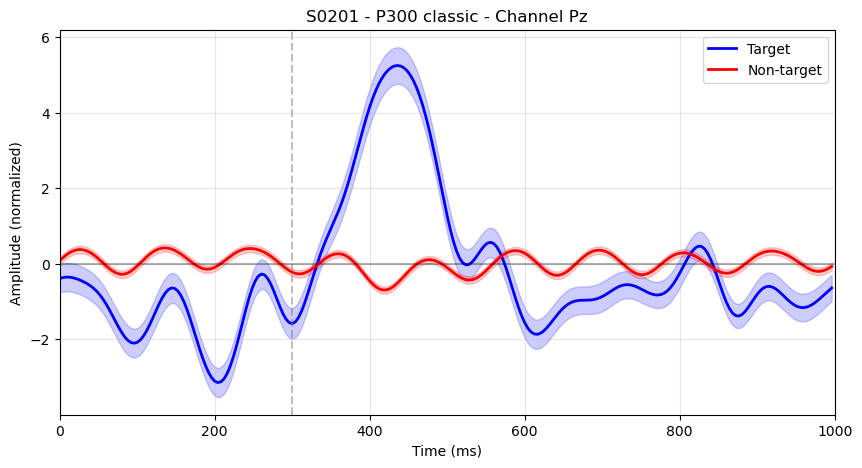

In [7]:
# Берем канал Pz (индекс 1)
ch_idx = 1  # Pz
ch_name = 'Pz'

# Разделяем на target и non-target
target_epochs = epochs[labels == 1, ch_idx, :]  # (n_target, 250)
nontarget_epochs = epochs[labels == 0, ch_idx, :]  # (n_nontarget, 250)

# Усредняем
target_mean = np.mean(target_epochs, axis=0)
target_std = np.std(target_epochs, axis=0)

nontarget_mean = np.mean(nontarget_epochs, axis=0)
nontarget_std = np.std(nontarget_epochs, axis=0)

# Время в миллисекундах
time = np.arange(epochs.shape[2]) / fs * 1000  # от 0 до 1000 мс

# Рисуем как в статье
plt.figure(figsize=(10, 5))
plt.plot(time, target_mean, 'b-', label='Target', linewidth=2)
plt.fill_between(time, 
                 target_mean - target_std/np.sqrt(len(target_epochs)), 
                 target_mean + target_std/np.sqrt(len(target_epochs)), 
                 alpha=0.2, color='blue')

plt.plot(time, nontarget_mean, 'r-', label='Non-target', linewidth=2)
plt.fill_between(time, 
                 nontarget_mean - nontarget_std/np.sqrt(len(nontarget_epochs)), 
                 nontarget_mean + nontarget_std/np.sqrt(len(nontarget_epochs)), 
                 alpha=0.2, color='red')

plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (normalized)')
plt.title(f'{light["subj"][0]} - {light["task"][0]} - Channel {ch_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1000)
plt.axvline(x=300, color='gray', linestyle='--', alpha=0.5)  # типичный пик P300
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.show()